In [1]:
import os
import pandas as pd

cwd = os.getcwd()

FUND_NAME = 'MM'

from utils.manage import PrivateFund

## A. Create a Fund

In [3]:
fund = PrivateFund(FUND_NAME, date='2026-01-01')

In [3]:
fund.log_fund_detail('full')

2026-01-02 17:04:29,603 - INFO - [Status] NAV: 1.0; Total share: 0.0; Fund balance: 0.0


## B. Load from File

In [2]:
FUND_PATH = os.path.join(cwd, 'fund_data')
fund = PrivateFund.load_fund(FUND_PATH, FUND_NAME)
fund.name = FUND_NAME

2026-02-28 17:31:57,867 - INFO - [Load] Fund MM from /Users/lizhifeng/Projects/FundRecord/fund_data/MM.2026-02-26.pkl


## C. Save to File

In [6]:
FUND_PATH = os.path.join(cwd, 'fund_data')
fund.save_fund(FUND_PATH)

2026-02-03 09:43:50,260 - INFO - [Save] Saving fund MM to /Users/lizhifeng/Projects/FundRecord/fund_data/MM.2026-02-03.pkl


## D. Invest

In [8]:
fund.invest("lmh", 1525.42 , '2026-01-01')

2026-01-02 17:05:28,195 - INFO - [Invest] lmh add 1525.42$; Share 1525.42
2026-01-02 17:05:28,197 - INFO - [Status] NAV: 1.0; Total share: 37629.9; Fund balance: 37629.9


## E. Redeem

In [7]:
fund.redeem("lmh", 34251.97   , 'balance', '2026-01-01')

2026-01-02 17:05:19,802 - INFO - [Redeem] lmh remove 34251.97 Share.
2026-01-02 17:05:19,804 - INFO - [Status] NAV: 1.0; Total share: 36104.48; Fund balance: 36104.48


0

## F. Update

In [3]:
fund.update_nav(12864.00 , '2026-02-28')

2026-02-28 17:32:05,442 - INFO - [Update] Balance 13822.000995 -> 12863.996805; NAV 0.829403 -> 0.771917


In [4]:
FUND_PATH = os.path.join(cwd, 'fund_data')
fund.save_fund(FUND_PATH)

2026-02-28 17:32:05,620 - INFO - [Save] Saving fund MM to /Users/lizhifeng/Projects/FundRecord/fund_data/MM.2026-02-28.pkl


## G. Transfer share

In [5]:
# # # fund.transfer('EMPTY', 'huangyuqi', 115.6-92.48, 'balance', '2025-06-07')
# # fund.transfer('wufangfang', 'lizhifeng', 15000 , 'balance', '2025-10-19')
# # fund.transfer('huangyuqi', 'gonghanhan', 7108.54 , 'balance', '2025-11-14')
# # fund.transfer('Empty', 'limingsheng', 4404.7 , 'balance', '2025-11-14')
# fund.transfer('tangjiahao', 'Family', 75 , 'balance', '2025-12-06')

## H. Log Status

## H. History Statistic

In [6]:
fund.get_fund_history()[['date', 'total_share', 'net_asset_value', 'balance']][-1:-20:-1]

,date,total_share,net_asset_value,balance
19,2026-02-28,16665.0,0.771917,12863.996805
18,2026-02-26,16665.0,0.829403,13822.000995
17,2026-02-23,16665.0,0.786979,13115.005035
16,2026-02-14,16665.0,0.833483,13889.994195
15,2026-02-11,16665.0,0.820762,13677.998730
14,2026-02-07,16665.0,0.838464,13973.002560
13,2026-02-06,16665.0,0.771137,12850.998105
12,2026-02-02,16665.0,0.880468,14672.999220
11,2026-01-30,16665.0,0.968677,16143.002205
10,2026-01-27,16665.0,1.000480,16672.999200


In [11]:
fund.get_investor_detail_df()

,Investor,Share,Balance
0,Family,9515.0,9660.59853
1,huangying,7150.0,7259.40930
2,Total,16665.0,16920.00783


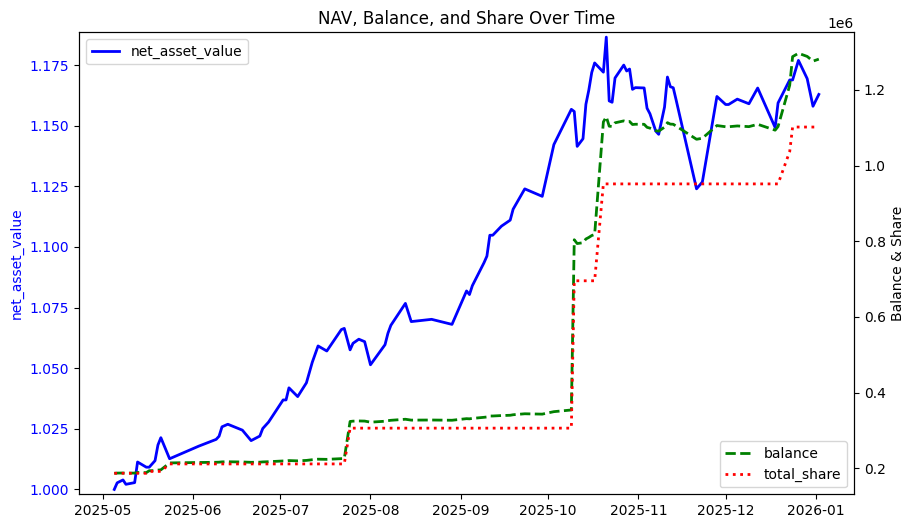

In [7]:
fund.draw_history()

## H. Reload Fund

In [151]:
import json

f = open('NeutralFund.json', 'w')

json.dump(fund.history_operation, f, ensure_ascii=False)
f.close()

In [156]:
fund.history_operation[-5:]

[['Transfer',
  {'investor_A_name': 'xuxiaoyan',
   'investor_B_name': 'EMPTY',
   'amount': 7650.57,
   'amount_type': 'balance',
   'date': '2025-11-14'},
  {'total_share': 212268.078541,
   'net_asset_value': 1.11411,
   'balance': 236489.988983}],
 ['Update',
  {'capital': 236279, 'date': '2025-11-21'},
  {'total_share': 212268.078541,
   'net_asset_value': 1.113116,
   'balance': 236278.994513}],
 ['Redeem',
  {'investor_name': 'EMPTY',
   'amount': 4124,
   'amount_type': 'balance',
   'date': '2025-11-21'},
  {'total_share': 208563.163689,
   'net_asset_value': 1.113116,
   'balance': 232154.994513}],
 ['Redeem',
  {'investor_name': 'EMPTY',
   'amount': 800,
   'amount_type': 'balance',
   'date': '2025-11-21'},
  {'total_share': 207844.460517,
   'net_asset_value': 1.113116,
   'balance': 231354.994513}],
 ['Transfer',
  {'investor_A_name': 'EMPTY',
   'investor_B_name': 'Family',
   'amount': 65.2,
   'amount_type': 'balance',
   'date': '2025-11-21'},
  {'total_share': 20784

In [5]:
for action, params, date in data:
    if action == 'Add':
        ...
    elif action == 'Invest':
        fund.invest(**params, date=date)
    elif action == 'Update':
        fund.update_nav(**params, date=date)
    elif action == 'Redeem':
        fund.redeem(**params, date=date)
    else:
        print(action)

2025-01-07 18:00:34,179 - INFO - [Add] No.1 Investor tanghongxuan
2025-01-07 18:00:34,180 - INFO - [Invest] tanghongxuan add 2851.32$; Share 2851.32
2025-01-07 18:00:34,181 - INFO - [Status] NAV: 1.0; Total share: 2851.32; Fund balance: 2851.32
2025-01-07 18:00:34,182 - INFO - [Add] No.2 Investor huangyuqi
2025-01-07 18:00:34,184 - INFO - [Invest] huangyuqi add 2988.62$; Share 2988.62
2025-01-07 18:00:34,184 - INFO - [Status] NAV: 1.0; Total share: 5839.94; Fund balance: 5839.94
2025-01-07 18:00:34,185 - INFO - [Add] No.3 Investor wufangfang
2025-01-07 18:00:34,185 - INFO - [Invest] wufangfang add 6926.6$; Share 6926.6
2025-01-07 18:00:34,186 - INFO - [Status] NAV: 1.0; Total share: 12766.54; Fund balance: 12766.54
2025-01-07 18:00:34,186 - INFO - [Add] No.4 Investor liminghua
2025-01-07 18:00:34,187 - INFO - [Invest] liminghua add 7254.1$; Share 7254.1
2025-01-07 18:00:34,188 - INFO - [Status] NAV: 1.0; Total share: 20020.64; Fund balance: 20020.64
2025-01-07 18:00:34,188 - INFO - [Ad